# 01. Creating Various Chart Types

## Using Matplotlib and Seaborn

## 📚 Learning Objectives

By completing this notebook, you will:
- Create various chart types (line, bar, scatter, histogram, etc.)
- Use Matplotlib for basic plotting
- Use Seaborn for statistical visualizations
- Choose appropriate chart types for your data
- Customize charts for presentations

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 2, lesson 05 "EDA: Visualizing Data Distributions" — the same charts, now chosen deliberately: which chart answers which question.

**Used later in:** Course 05 — Unit 3, lessons 02-08, which go deeper on each library, and Course 12 (AIAT 126) — Unit 5.

---

This notebook covers practical activities from **Course 05, Unit 3**:
- Creating various chart types using Matplotlib and Seaborn

---

## The Story: Learning to Draw

Imagine you're learning to draw. **Before** creating masterpieces, you learn basic shapes - circles, squares, lines. **After** mastering basics, you can combine them into complex drawings!

Same with visualization: **Before** creating advanced dashboards, we learn basic chart types - line, bar, scatter. **After** mastering basics, we can create any visualization!

---

## Why Chart Types Matter

Understanding chart types is essential because:
- **Right Tool**: Each chart type shows different insights
- **Communication**: Visuals communicate better than tables
- **Decision Making**: Charts help make data-driven decisions
- **Professionalism**: Good charts impress stakeholders

**Common Student Questions:**
- **Q: Which chart should I use?**
  - Answer: Depends on your data and goal
  - Example: Trends over time → line plot, Compare categories → bar chart
  - Rule: Time series → line, Categories → bar, Relationships → scatter
  
- **Q: Matplotlib vs Seaborn?**
  - Answer: Matplotlib for basic plots, Seaborn for statistical plots
  - Example: Simple bar chart → matplotlib, Statistical distribution → seaborn
  - Tip: Start with matplotlib, use seaborn for advanced statistics

---

## Introduction

**Matplotlib and Seaborn** provide comprehensive tools for creating various chart types. Understanding when to use each chart type is essential for effective data visualization and communication.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `border_crossing_data.csv` — inbound crossings at every U.S. land border port, monthly 1996-2019
- matplotlib, seaborn

**Outputs:** What you'll see when you run the cells

- Line, bar, histogram, scatter, etc.
- Figures

---

In [1]:
# WHAT: Import plotting libraries, set a consistent style, and load the real US border-crossing log.
# WHY: One shared REAL dataset lets every chart type below be compared fairly - and forces each chart to survive real skew and real gaps.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported!")
print("\n" + "=" * 70)
print("Chart Types: Matplotlib and Seaborn")
print("=" * 70)

# ============================================================================
# PART 1: THE DATA
# ============================================================================
print("-" * 70)

# Every inbound crossing counted at every US land border port, monthly, since 1996.
# Published by the US Bureau of Transportation Statistics.
DATA_DIR = '../../../Course 04/datasets/raw/'
df = pd.read_csv(DATA_DIR + 'border_crossing_data.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')

# Two reshaped views we will need:
# 1) monthly total traffic - a genuine time series for line charts
monthly = df.groupby('Date')['Value'].sum()
# 2) one row per (port, month) with a column per crossing type - for scatter/heatmap
wide = df.pivot_table(index=['Port Name', 'Date'], columns='Measure',
                      values='Value', aggfunc='sum')

print(f"Loaded {len(df):,} records, {df['Port Name'].nunique()} ports,"
      f" {df['Measure'].nunique()} crossing types")
print(f"Time span: {df['Date'].min():%b %Y} to {df['Date'].max():%b %Y}"
      f" ({len(monthly)} months)")
print(f"Reshaped wide table: {wide.shape[0]:,} port-months x {wide.shape[1]} measures")


✅ Libraries imported!

Chart Types: Matplotlib and Seaborn
----------------------------------------------------------------------


Loaded 346,733 records, 116 ports, 12 crossing types
Time span: Jan 1996 to Mar 2019 (279 months)
Reshaped wide table: 30,066 port-months x 12 measures


Real data loaded:
       Port Name       State            Border       Date  \
0  Calexico East  California  US-Mexico Border 2019-03-01   
1      Van Buren       Maine  US-Canada Border 2019-03-01   
2      Otay Mesa  California  US-Mexico Border 2019-03-01   
3        Nogales     Arizona  US-Mexico Border 2019-03-01   
4    Trout River    New York  US-Canada Border 2019-03-01   

                       Measure  Value  
0                       Trucks  34447  
1         Rail Containers Full    428  
2                       Trucks  81217  
3                       Trains     62  
4  Personal Vehicle Passengers  16377  

PART 2: Matplotlib Chart Types

✅ Example 1: Line Plot (Trends Over Time)
----------------------------------------------------------------------


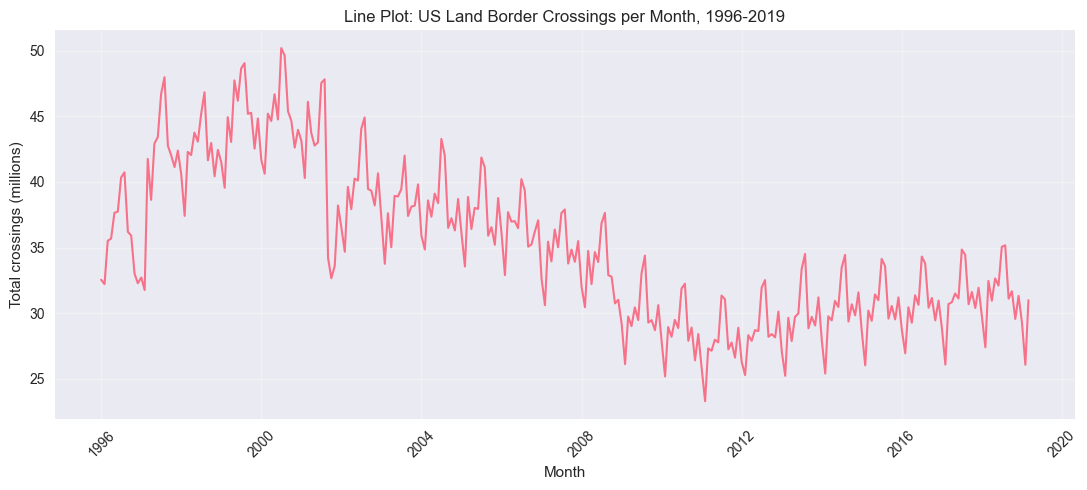

💡 Use for: Trends over time, continuous data
   The line shows a real long-term decline: the busiest month on record was Jul 2000 (50.2M crossings),
   against 31.0M in Mar 2019.
   Only a time-ordered line makes that shape visible at a glance.

✅ Example 2: Bar Chart (Categorical Comparison)
----------------------------------------------------------------------
   (the bar chart is finished and shown in the next cell)


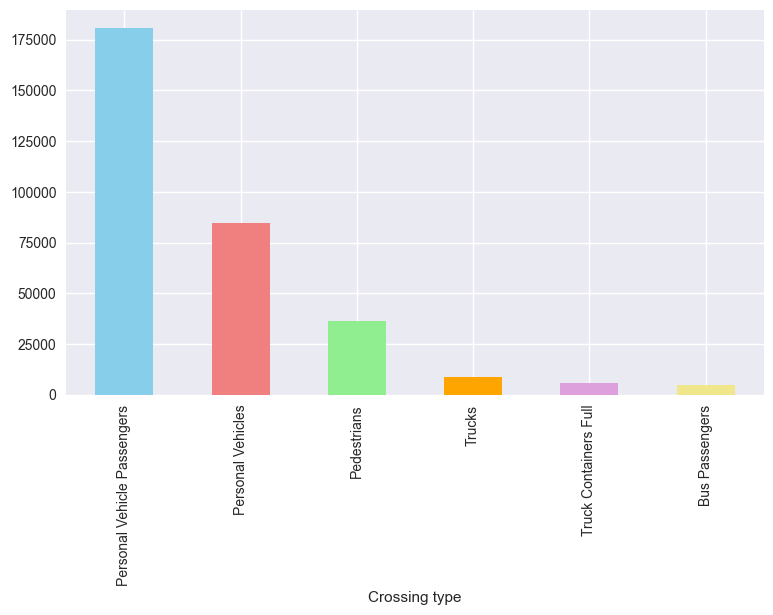

In [2]:
# WHAT: Preview the data, then draw a line plot of monthly border traffic over time.
# WHY: Line plots are THE chart for trends - connected points emphasize change between moments.

print("Real data loaded:")
print(df[['Port Name', 'State', 'Border', 'Date', 'Measure', 'Value']].head())

# ============================================================================
# PART 2: MATPLOTLIB CHART TYPES
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Matplotlib Chart Types")
print("=" * 70)

# Line Plot
print("\n✅ Example 1: Line Plot (Trends Over Time)")
print("-" * 70)
plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values / 1e6, linewidth=1.5)
plt.xlabel('Month')
plt.ylabel('Total crossings (millions)')
plt.title('Line Plot: US Land Border Crossings per Month, 1996-2019')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("💡 Use for: Trends over time, continuous data")
peak_month = monthly.idxmax()
print(f"   The line shows a real long-term decline: the busiest month on record was"
      f" {peak_month:%b %Y} ({monthly.max() / 1e6:.1f}M crossings),")
print(f"   against {monthly.iloc[-1] / 1e6:.1f}M in {monthly.index[-1]:%b %Y}.")
print("   Only a time-ordered line makes that shape visible at a glance.")

# Bar Chart
print("\n✅ Example 2: Bar Chart (Categorical Comparison)")
print("-" * 70)
category_means = df.groupby('Measure')['Value'].mean().sort_values(ascending=False).head(6)
plt.figure(figsize=(9, 5))
category_means.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen',
                                       'orange', 'plum', 'khaki'])
plt.xlabel('Crossing type')
print("   (the bar chart is finished and shown in the next cell)")


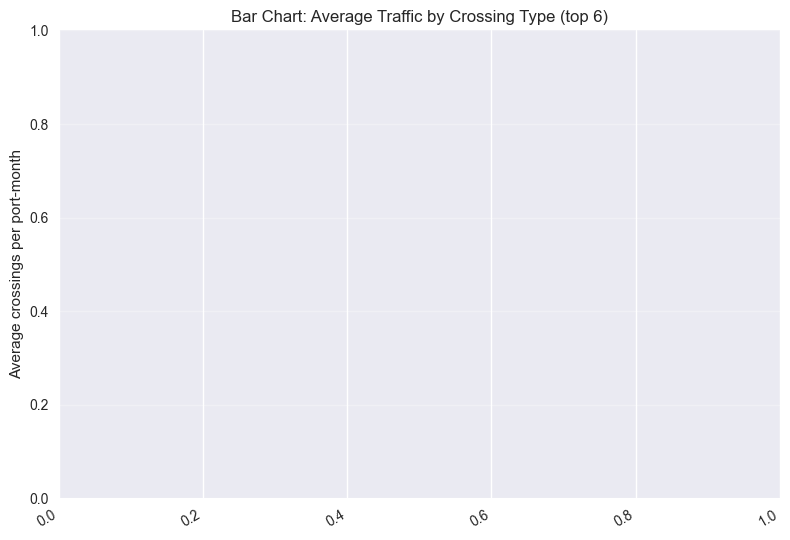

💡 Use for: Comparing categories, discrete data
   Averages per port-month:
Measure
Personal Vehicle Passengers    180732.0
Personal Vehicles               84705.0
Pedestrians                     36388.0
Trucks                           8496.0
Truck Containers Full            5967.0
Bus Passengers                   4939.0

✅ Example 3: Scatter Plot (Relationships)
----------------------------------------------------------------------


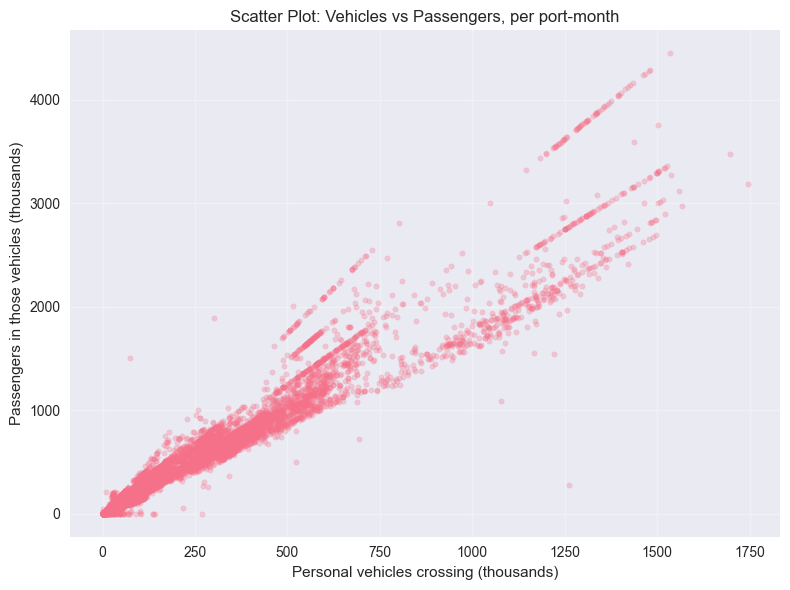

💡 Use for: Relationships, correlations, patterns
   These two measures move together almost perfectly (r = 0.98) -
   unsurprising, since every car carries people. The slope of the cloud is
   the average occupancy: about 2.1 people per vehicle.
   A scatter can measure something the two separate columns never showed.

✅ Example 4: Histogram (Distribution)
----------------------------------------------------------------------


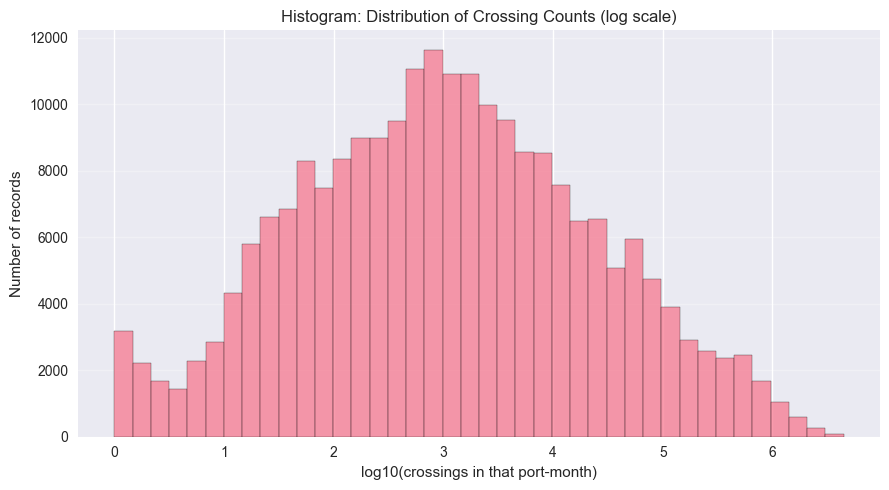

In [3]:
# WHAT: Finish the bar chart, then draw a scatter plot and start a histogram - all on the real crossing data.
# WHY: Bars compare categories; scatters expose relationships between two variables - matching chart to question is the core skill.

plt.ylabel('Average crossings per port-month')
plt.title('Bar Chart: Average Traffic by Crossing Type (top 6)')
plt.xticks(rotation=30, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("💡 Use for: Comparing categories, discrete data")
print("   Averages per port-month:")
print(category_means.round(0).to_string())

# Scatter Plot
print("\n✅ Example 3: Scatter Plot (Relationships)")
print("-" * 70)
# Each point is ONE port in ONE month: how many cars crossed, and how many people
# were in them. dropna() is needed because not every port reports every measure.
pair = wide[['Personal Vehicles', 'Personal Vehicle Passengers']].dropna()
plt.figure(figsize=(8, 6))
plt.scatter(pair['Personal Vehicles'] / 1000,
            pair['Personal Vehicle Passengers'] / 1000, alpha=0.3, s=15)
plt.xlabel('Personal vehicles crossing (thousands)')
plt.ylabel('Passengers in those vehicles (thousands)')
plt.title('Scatter Plot: Vehicles vs Passengers, per port-month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
r = pair['Personal Vehicles'].corr(pair['Personal Vehicle Passengers'])
print("💡 Use for: Relationships, correlations, patterns")
print(f"   These two measures move together almost perfectly (r = {r:.2f}) -")
print("   unsurprising, since every car carries people. The slope of the cloud is")
print(f"   the average occupancy: about"
      f" {pair['Personal Vehicle Passengers'].sum() / pair['Personal Vehicles'].sum():.1f}"
      " people per vehicle.")
print("   A scatter can measure something the two separate columns never showed.")

# Histogram
print("\n✅ Example 4: Histogram (Distribution)")
print("-" * 70)
plt.figure(figsize=(9, 5))
# The raw Value column spans 0 to 4.4 million, so a linear histogram is one tall
# bar and 19 empty ones. log10 makes the real shape readable - and the axis label
# must say so, or the chart lies.
positive = df.loc[df['Value'] > 0, 'Value']
plt.hist(np.log10(positive), bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('log10(crossings in that port-month)')
plt.ylabel('Number of records')
plt.title('Histogram: Distribution of Crossing Counts (log scale)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


💡 Use for: Distributions, frequency, spread
   Raw range: 0 to 4,447,374 crossings.
   122,387 records are exactly 0 and had to be
   excluded before taking a logarithm - a real decision the data forced.

PART 3: Seaborn Chart Types

✅ Example 5: Box Plot (Statistical Summary)
----------------------------------------------------------------------


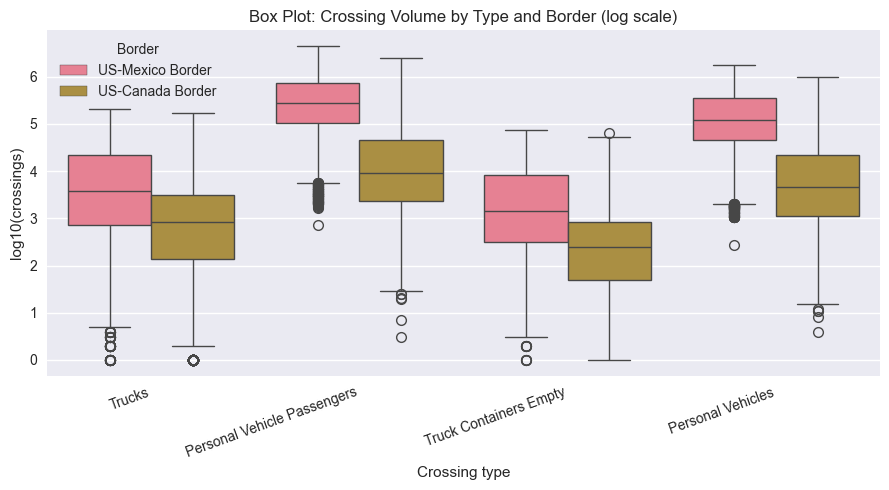

💡 Use for: Quartiles, outliers, distributions by category
   Median crossings per record, within the four types plotted:
     US-Mexico 41,878 vs US-Canada 1,853.
   The boxes sit at visibly different heights - a comparison that a single
   combined histogram would have hidden completely.

✅ Example 6: Heatmap (Correlation Matrix)
----------------------------------------------------------------------


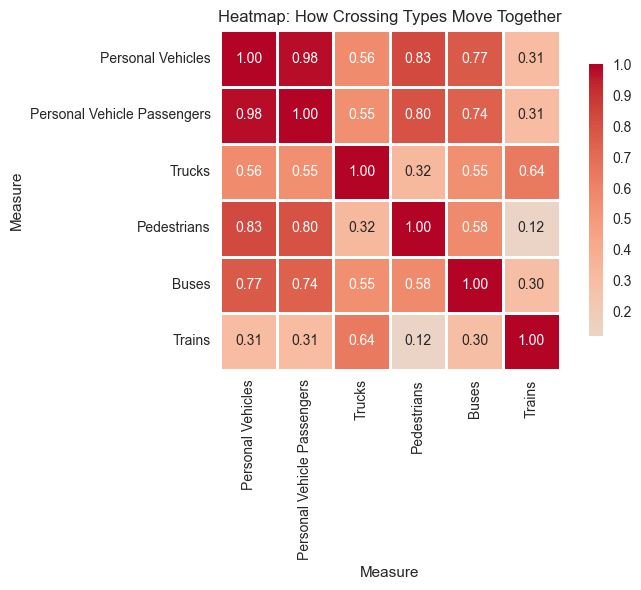

In [4]:
# WHAT: Finish the histogram, then start seaborn's statistical charts (box plot, heatmap) on the real data.
# WHY: Seaborn adds statistics on top of matplotlib - a box plot encodes median, quartiles, and outliers in one glyph.

print("💡 Use for: Distributions, frequency, spread")
print(f"   Raw range: {df['Value'].min():,.0f} to {df['Value'].max():,.0f} crossings.")
print(f"   {int((df['Value'] == 0).sum()):,} records are exactly 0 and had to be")
print("   excluded before taking a logarithm - a real decision the data forced.")

# ============================================================================
# PART 3: SEABORN CHART TYPES
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Seaborn Chart Types")
print("=" * 70)

# Box Plot
print("\n✅ Example 5: Box Plot (Statistical Summary)")
print("-" * 70)
top4 = df['Measure'].value_counts().head(4).index.tolist()
subset = df[df['Measure'].isin(top4) & (df['Value'] > 0)].copy()
subset['log_value'] = np.log10(subset['Value'])
plt.figure(figsize=(9, 5))
sns.boxplot(data=subset, x='Measure', y='log_value', hue='Border')
plt.title('Box Plot: Crossing Volume by Type and Border (log scale)')
plt.xlabel('Crossing type')
plt.ylabel('log10(crossings)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
print("💡 Use for: Quartiles, outliers, distributions by category")
med = subset.groupby('Border')['Value'].median()
print(f"   Median crossings per record, within the four types plotted:")
print(f"     US-Mexico {med.get('US-Mexico Border', 0):,.0f} vs US-Canada {med.get('US-Canada Border', 0):,.0f}.")
print("   The boxes sit at visibly different heights - a comparison that a single")
print("   combined histogram would have hidden completely.")

# Heatmap
print("\n✅ Example 6: Heatmap (Correlation Matrix)")
print("-" * 70)
measures = ['Personal Vehicles', 'Personal Vehicle Passengers', 'Trucks',
            'Pedestrians', 'Buses', 'Trains']
correlation_data = wide[measures].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Heatmap: How Crossing Types Move Together')
plt.tight_layout()


In [5]:
# WHAT: Finish the heatmap and print a chart-selection guide organized by goal.
# WHY: Choosing by GOAL (distribution, relationship, comparison, composition) beats choosing by what looks nice.

plt.show()
print("💡 Use for: Correlations, patterns in matrix data")
print(f"   Strongest pair: Personal Vehicles ↔ Passengers"
      f" ({correlation_data.loc['Personal Vehicles', 'Personal Vehicle Passengers']:.2f})")
print(f"   Weakest pair shown: Trains ↔ Pedestrians"
      f" ({correlation_data.loc['Trains', 'Pedestrians']:.2f}) - rail freight and people")
print("   walking across a bridge are simply different kinds of traffic.")
print("   One glance at the matrix replaces 15 separate scatter plots.")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("PART 4: Chart Selection Guide")
print("=" * 70)

selection_guide = {
    "Distribution": {
        "charts": ["Histogram", "Box Plot", "Violin Plot", "KDE"],
        "use_case": "Show how data is distributed"
    },
    "Relationships": {
        "charts": ["Scatter Plot", "Line Plot", "Correlation Heatmap"],
        "use_case": "Show relationships between variables"
    },
    "Comparisons": {
        "charts": ["Bar Chart", "Box Plot", "Grouped Bar"],
        "use_case": "Compare categories or groups"
    },
    "Composition": {
        "charts": ["Pie Chart", "Stacked Bar", "Area Chart"],
        "use_case": "Show parts of a whole"
    }
}

for purpose, info in selection_guide.items():
    print(f"\n📊 {purpose}:")
    print(f"   Charts: {', '.join(info['charts'])}")
    print(f"   Use case: {info['use_case']}")


💡 Use for: Correlations, patterns in matrix data
   Strongest pair: Personal Vehicles ↔ Passengers (0.98)
   Weakest pair shown: Trains ↔ Pedestrians (0.12) - rail freight and people
   walking across a bridge are simply different kinds of traffic.
   One glance at the matrix replaces 15 separate scatter plots.

PART 4: Chart Selection Guide

📊 Distribution:
   Charts: Histogram, Box Plot, Violin Plot, KDE
   Use case: Show how data is distributed

📊 Relationships:
   Charts: Scatter Plot, Line Plot, Correlation Heatmap
   Use case: Show relationships between variables

📊 Comparisons:
   Charts: Bar Chart, Box Plot, Grouped Bar
   Use case: Compare categories or groups

📊 Composition:
   Charts: Pie Chart, Stacked Bar, Area Chart
   Use case: Show parts of a whole


In [6]:
# WHAT: Print the notebook summary.
# WHY: The one-line rules here (distribution -> histogram, relationship -> scatter) are worth memorizing.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("""
✅ What you learned:
   1. Matplotlib Charts: Line, bar, scatter, histogram (basic plots)
   2. Seaborn Charts: Box plot, heatmap, distribution plots (statistical)
   3. Chart Selection: Choose based on data type and goal
   4. When to Use: Distribution → histogram, Relationships → scatter
   5. Real data forces real decisions: log scales for skewed counts,
      dropna() before a scatter, zeros excluded before a logarithm

🎯 Key Takeaways:
   - Matplotlib: Basic, customizable plots
   - Seaborn: Statistical, beautiful plots
   - Choose chart based on: Data type, goal, audience

📚 Next Steps:
   - Example 02: Matplotlib Basics (more details)
   - Example 03: Seaborn Plots (advanced statistical charts)
   - Examples 04-05: Interactive Visualizations (Plotly)
""")
print("✅ Chart types concepts understood!")



Summary

✅ What you learned:
   1. Matplotlib Charts: Line, bar, scatter, histogram (basic plots)
   2. Seaborn Charts: Box plot, heatmap, distribution plots (statistical)
   3. Chart Selection: Choose based on data type and goal
   4. When to Use: Distribution → histogram, Relationships → scatter
   5. Real data forces real decisions: log scales for skewed counts,
      dropna() before a scatter, zeros excluded before a logarithm

🎯 Key Takeaways:
   - Matplotlib: Basic, customizable plots
   - Seaborn: Statistical, beautiful plots
   - Choose chart based on: Data type, goal, audience

📚 Next Steps:
   - Example 02: Matplotlib Basics (more details)
   - Example 03: Seaborn Plots (advanced statistical charts)
   - Examples 04-05: Interactive Visualizations (Plotly)

✅ Chart types concepts understood!


## 📚 References

1. Cleveland, W. S., & McGill, R. (1984). *Graphical Perception: Theory, Experimentation, and Application to the Development of Graphical Methods*. Journal of the American Statistical Association, 79(387), 531-554. <https://doi.org/10.1080/01621459.1984.10478080>
2. Tufte, E. R. (2001). *The Visual Display of Quantitative Information*, 2nd ed. Graphics Press.
3. Waskom, M. L. (2021). *seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021. <https://joss.theoj.org/papers/10.21105/joss.03021>